# Interaktive Analyse & Metriken-Explorer

Dieses Notebook importiert die modularisierten Analyse- und Vergleichswerkzeuge aus dem `utils_notebook`-Ordner und führt sie nacheinander aus.

## Phase 0

In [1]:
import sys
import os

# Pfad anpassen, um utils_notebook importieren zu können
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

# Nur noch die benötigten Imports aus dem L&R-Modul
from utils_notebook.LR_utils_notebook.compare_LR import (
    compare_wunden_interactive, 
    compare_categories_interactive,
    calculate_summary_LR,
    display_summary_LR,
    calculate_experts_summary_LR,
    compare_wunden_trace_interactive,
    compare_categories_trace_interactive,
    calculate_consensus_summary_LR
)
from utils_notebook.plot_compare import plot_gt_comparison

from utils_notebook.LR_utils_notebook.product_sets_comparison import display_product_sets_comparison

FEW_SHOT_RAW = "../../data/llm_outputs/few_shot_lr/few_shot_lr_raw.csv"
FEW_SHOT_NORM = "../../data/llm_outputs/few_shot_lr/few_shot_lr_normalised.csv"

In [2]:
compare_wunden_interactive(normalised=False, path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)

In [3]:
compare_categories_interactive(normalised=False, path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)

## Phase 2

In [4]:
compare_wunden_interactive(normalised=True, path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)
compare_categories_interactive(normalised=True, path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)

Diagramm für Experte 1 wird generiert...


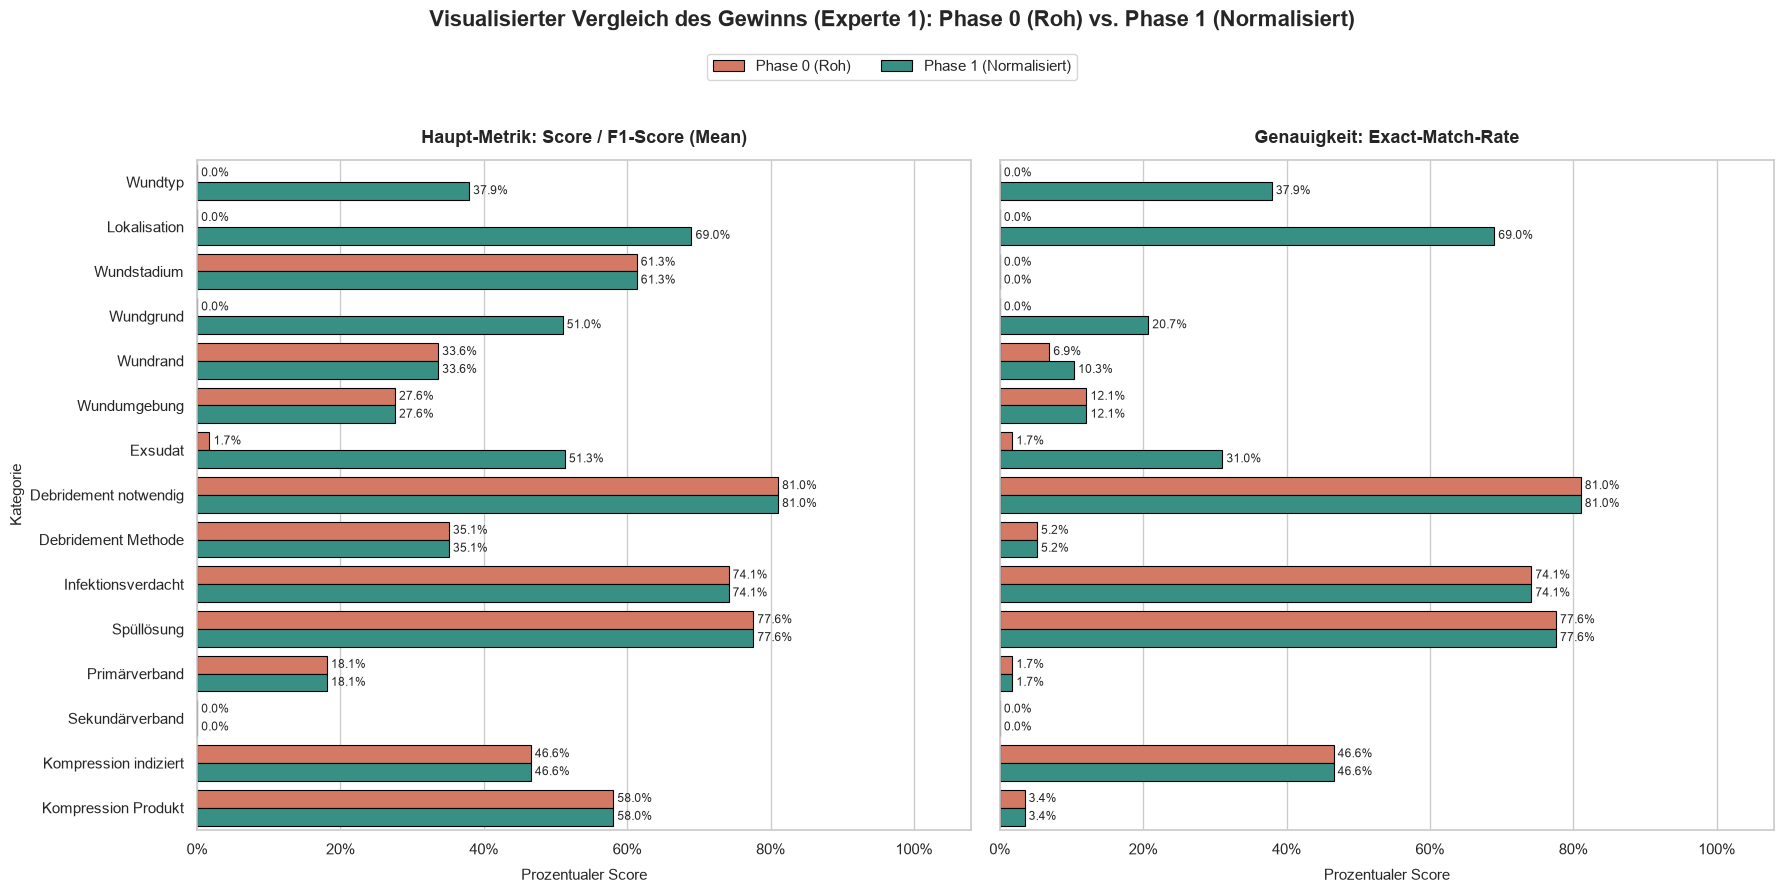

Diagramm für Experte 2 wird generiert...


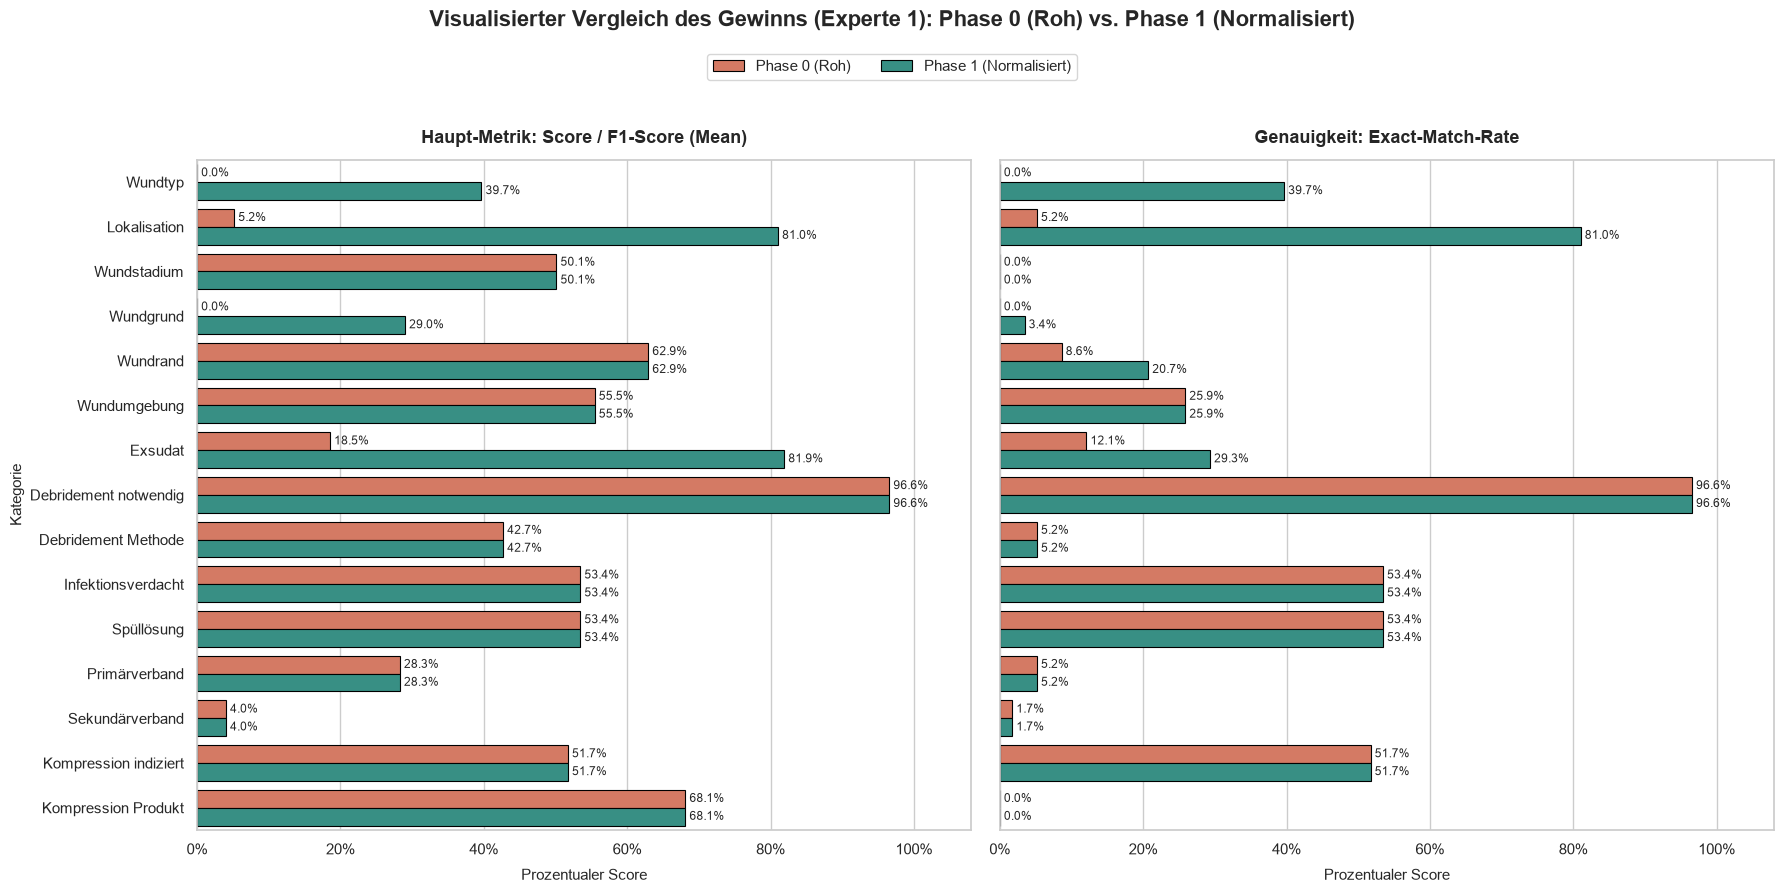

In [5]:
# Berechne die Zusammenfassungen für Experte 1 (Roh vs. Normalisiert)
df_sum1_raw = calculate_summary_LR(expert_id=1, normalised=False, path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)
df_sum1_norm = calculate_summary_LR(expert_id=1, normalised=True, path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)

# Zeichne das Vergleichsdiagramm
print("Diagramm für Experte 1 wird generiert...")
plot_gt_comparison(df_sum1_raw, df_sum1_norm)

# Berechne die Zusammenfassungen für Experte 2 (Roh vs. Normalisiert)
df_sum2_raw = calculate_summary_LR(expert_id=2, normalised=False, path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)
df_sum2_norm = calculate_summary_LR(expert_id=2, normalised=True, path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)

# Zeichne das Vergleichsdiagramm
print("Diagramm für Experte 2 wird generiert...")
plot_gt_comparison(df_sum2_raw, df_sum2_norm)

In [6]:
compare_wunden_trace_interactive()
compare_categories_trace_interactive()

Diagramm für den Konsens-Score (Best-of-Both-Experts) wird generiert...


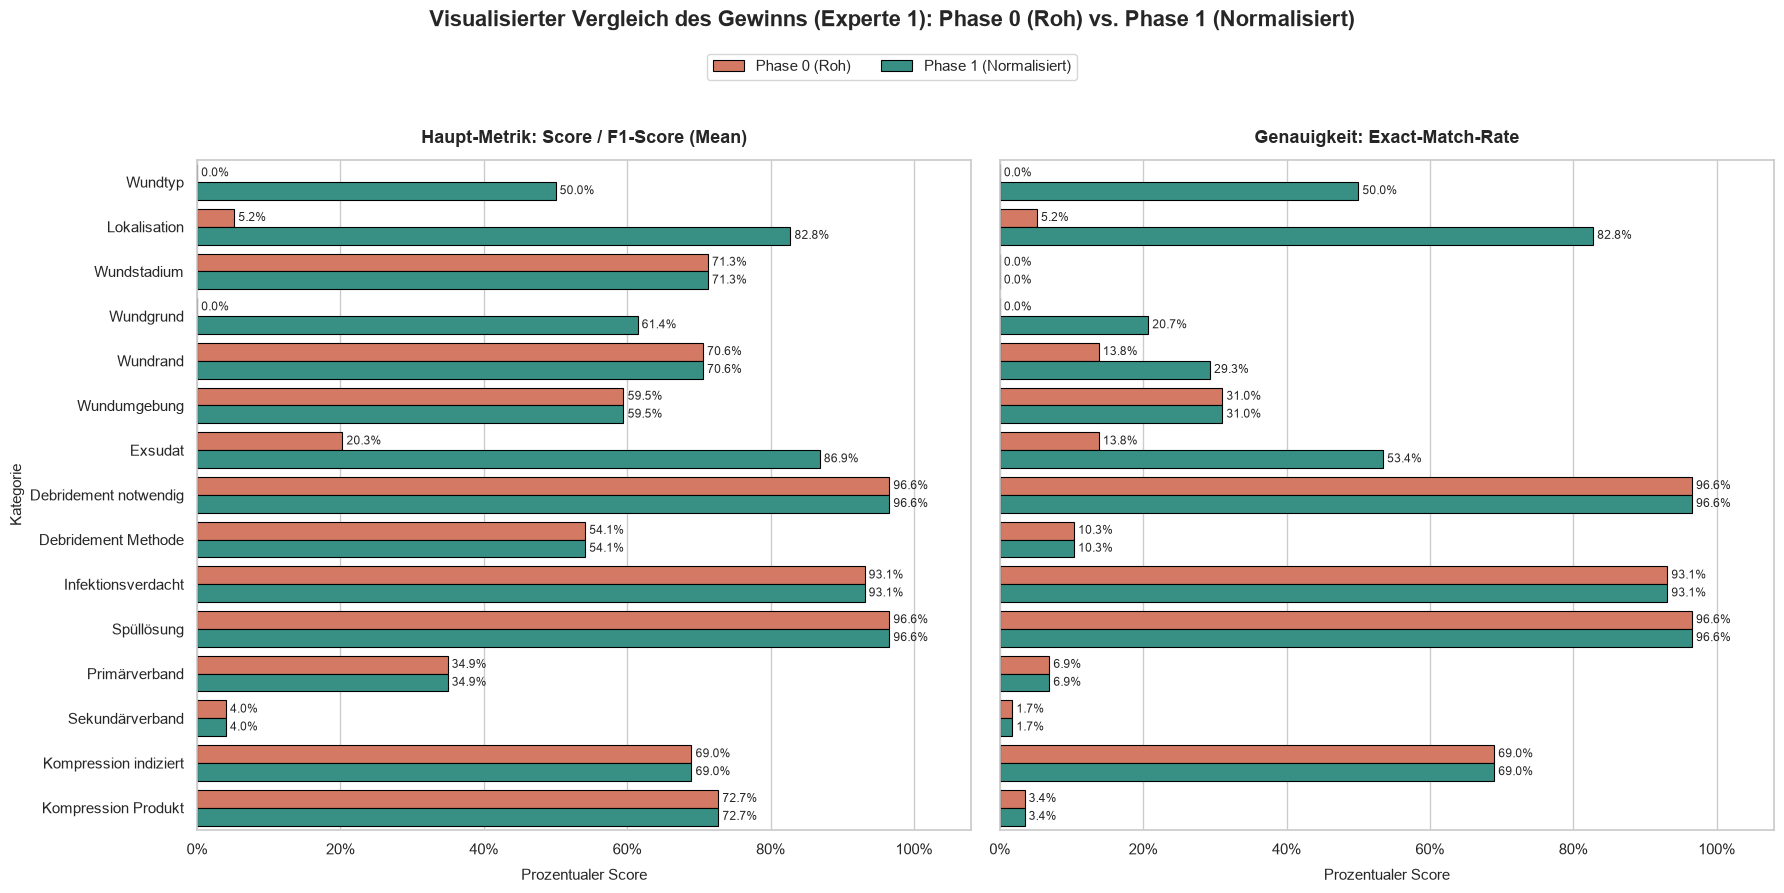

In [7]:
# 1. Berechne Konsens-Zusammenfassung (Maximum aus Experte 1 und Experte 2)
df_consensus_raw = calculate_consensus_summary_LR(normalised=False, path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)
df_consensus_norm = calculate_consensus_summary_LR(normalised=True, path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)

# 2. Zeichne das Vergleichsdiagramm für den Konsens-Score
print("Diagramm für den Konsens-Score (Best-of-Both-Experts) wird generiert...")
plot_gt_comparison(df_consensus_raw, df_consensus_norm)


In [8]:
# Berechnet und zeigt die F1-Produktset-Vergleiche der normalisierten Few-Shot Ergebnisse an
df_summary, df_detail = display_product_sets_comparison(path_llm=FEW_SHOT_NORM)


Metrik / Vergleich,Score / F1-Score
Experten-Einigkeit untereinander (F1 Mean),33.5%
LLM vs. Experte 1 (F1 Mean),14.3%
LLM vs. Experte 2 (F1 Mean),21.2%
LLM Best Match (Max F1 Mean),24.4%
LLM Durchschnitt (Mean F1),17.7%


image_id,Experte 1 Produktset,Experte 2 Produktset,LLM Output Produktset,Experten-Einigkeit (F1),LLM vs Exp 1 (F1),LLM vs Exp 2 (F1),LLM Best Match (F1),LLM Mean (F1)
wunde_01,"debrisoft pad, suprasorb cnp","chirurgisches debridement, debrisoft lolly, suprasorb cnp, suprasorb x + phmb","autolytisches debridement, chirurgisches debridement, curafix h, debrisoft duo, debrisoft lolly, haftelast latexfrei, porofix, silkafix, suprasorb a + ag, vliwaktiv ag, vliwasorb pro, vliwazell pro",33.3%,0.0%,25.0%,25.0%,12.5%
wunde_02,"debrisoft pad, fixierbinden und universalbinden. rollenpflaster, solvaline n, suprasorb p + phmb","chirurgisches debridement, debrisoft duo, solvaline n, suprasorb cnp, suprasorb x + phmb","curafix h, debrisoft pad, metalline kompresse, silkafix, suprasorb x",22.2%,22.2%,0.0%,22.2%,11.1%
wunde_03,suprasorb p sensiflex,"lomatuell pro, solvaline n, suprasorb p sensiflex","curafix h, silkafix, suprasorb p, suprasorb p sensitive",50.0%,0.0%,0.0%,0.0%,0.0%
wunde_05,"debrisoft duo, solvaline n, suprasorb x + phmb","chirurgisches debridement, lomatuell h, suprasorb x + phmb","autolytisches debridement, chirurgisches debridement, curafix h, curapor transparent, debrisoft duo, porofix, silkafix, suprasorb a + ag, suprasorb x + phmb, vliwasorb sensitive, vliwazell pro",33.3%,28.6%,28.6%,28.6%,28.6%
wunde_06,"fixierbinde und rollenpflaster, solvaline n, suprasorb x + phmb","chirurgisches debridement, debrisoft duo, solvaline n, suprasorb p + phmb","autolytisches debridement, curafix h, curapor transparent, debrisoft pad, lomatuell pro, porofix, silkafix, suprasorb p sensiflex, suprasorb p sensitive, suprasorb x",28.6%,0.0%,0.0%,0.0%,0.0%
wunde_07,"suprasorb cnp, ultraschall","debrisoft pad, lomatuell pro, suprasorb cnp, vliwazell pro","autolytisches debridement, curafix h, debrisoft duo, silkafix, suprasorb liquacel pro, suprasorb p sensitive",33.3%,0.0%,0.0%,0.0%,0.0%
wunde_08,suprasorb p sensiflex,—,"metalline kompresse, porofix, silkafix, suprasorb f protect",0.0%,0.0%,0.0%,0.0%,0.0%
wunde_09,—,"chirurgisches debridement, debrisoft duo","autolytisches debridement, chirurgisches debridement, curapor transparent, debrisoft duo, haftelast latexfrei, mollelast haft latexfrei, suprasorb g gel-kompresse, suprasorb x pro, tg schlauchverband",0.0%,0.0%,36.4%,36.4%,18.2%
wunde_10,"debrisoft duo, suprasorb f protect, suprasorb g gel-kompresse","chirurgisches debridement, debrisoft pad, solvaline n, suprasorb cnp, suprasorb liquacel pro, suprasorb x + phmb, vliwazell pro","chirurgisches debridement, curafix h, debrisoft duo, haftelast latexfrei, mollelast haft latexfrei, silkafix, suprasorb a + ag, suprasorb p + phmb, vliwazell pro",0.0%,16.7%,25.0%,25.0%,20.8%
wunde_11,"autolytisches debridement, suprasorb f protect, suprasorb g gel-kompresse","autolytisches debridement, chirurgisches debridement, solvaline n, suprasorb g gel-kompresse, suprasorb x + phmb, vliwazell pro","actifast, autolytisches debridement, debrisoft duo, haftelast latexfrei, mollelast haft latexfrei, suprasorb a + ag, suprasorb p, suprasorb p sensitive, suprasorb x + phmb, tg schlauchverband",44.4%,15.4%,25.0%,25.0%,20.2%


In [9]:
compare_wunden_trace_interactive(path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)


In [10]:
from utils_notebook.LR_utils_notebook.product_sets_comparison import display_product_sets_comparison

# Führt die Berechnung aus und zeigt Zusammenfassung sowie Detailtabelle im L&R Design an:
df_summary, df_detail = display_product_sets_comparison()

Metrik / Vergleich,Score / F1-Score
Experten-Einigkeit untereinander (F1 Mean),33.3%
LLM vs. Experte 1 (F1 Mean),13.7%
LLM vs. Experte 2 (F1 Mean),20.7%
LLM Best Match (Max F1 Mean),23.9%
LLM Durchschnitt (Mean F1),17.2%


image_id,Experte 1 Produktset,Experte 2 Produktset,LLM Output Produktset,Experten-Einigkeit (F1),LLM vs Exp 1 (F1),LLM vs Exp 2 (F1),LLM Best Match (F1),LLM Mean (F1)
wunde_01,"debrisoft pad, suprasorb cnp","chirurgisches debridement, debrisoft lolly, suprasorb cnp, suprasorb x + phmb","autolytisches debridement, chirurgisches (scharfes) debridement, curafix h, debrisoft duo, porofix, silkafix, suprasorb a + ag, vliwaktiv ag, vliwasorb pro",33.3%,0.0%,0.0%,0.0%,0.0%
wunde_02,"debrisoft pad, fixierbinden und universalbinden. rollenpflaster, solvaline n, suprasorb p + phmb","chirurgisches debridement, debrisoft duo, solvaline n, suprasorb cnp, suprasorb x + phmb","curafix h, haftelast latexfrei, metalline kompresse, suprasorb p sensitive, suprasorb x, vliwazell",22.2%,0.0%,0.0%,0.0%,0.0%
wunde_03,suprasorb p sensiflex,"lomatuell pro, solvaline n, suprasorb p sensiflex","curafix h, lomatuell pro, silkafix, suprasorb liquacel pro, suprasorb p sensitive",50.0%,0.0%,25.0%,25.0%,12.5%
wunde_04,"debrisoft pad, solvaline n, suprasorb x + phmb, universalbinde und rollenpflaster","chirurgisches debridement, debrisoft lolly, suprasorb a + ag, suprasorb p + phmb, suprasorb p sensiflex","chirurgisches debridement, curafix h, debrisoft duo, porofix, silkafix, suprasorb a + ag, suprasorb p + phmb, suprasorb p sensitive",0.0%,0.0%,46.2%,46.2%,23.1%
wunde_05,"debrisoft duo, solvaline n, suprasorb x + phmb","chirurgisches debridement, lomatuell h, suprasorb x + phmb","autolytisches debridement, chirurgisches debridement, curafix h, debrisoft duo, porofix, silkafix, suprasorb a + ag, suprasorb liquacel pro, vliwasorb pro, vliwazell pro",33.3%,15.4%,15.4%,15.4%,15.4%
wunde_06,"fixierbinde und rollenpflaster, solvaline n, suprasorb x + phmb","chirurgisches debridement, debrisoft duo, solvaline n, suprasorb p + phmb","chirurgisches debridement, curafix h, debrisoft pad, lomatuell pro, porofix, silkafix, suprasorb p sensiflex, suprasorb p sensitive, suprasorb x pro",28.6%,0.0%,15.4%,15.4%,7.7%
wunde_07,"suprasorb cnp, ultraschall","debrisoft pad, lomatuell pro, suprasorb cnp, vliwazell pro","autolytisches debridement, curafix h, debrisoft duo, debrisoft pad, silkafix, suprasorb a pro, suprasorb liquacel pro, suprasorb p",33.3%,0.0%,16.7%,16.7%,8.3%
wunde_08,suprasorb p sensiflex,—,"autolytisches debridement, curafix h, curapor, curapor transparent, debrisoft pad, silkafix, suprasorb x, suprasorb x pro",0.0%,0.0%,0.0%,0.0%,0.0%
wunde_09,—,"chirurgisches debridement, debrisoft duo","autolytisches debridement, chirurgisches debridement, curafix h, debrisoft duo, porofix, silkafix, suprasorb f protect, suprasorb g gel-kompresse, suprasorb h",0.0%,0.0%,36.4%,36.4%,18.2%
wunde_10,"debrisoft duo, suprasorb f protect, suprasorb g gel-kompresse","chirurgisches debridement, debrisoft pad, solvaline n, suprasorb cnp, suprasorb liquacel pro, suprasorb x + phmb, vliwazell pro","autolytisches debridement, chirurgisches debridement, curafix h, debrisoft duo, porofix, suprasorb a pro, suprasorb liquacel pro, suprasorb p sensitive, vliwasorb pro",0.0%,16.7%,25.0%,25.0%,20.8%


=== 1. SCORE-EINIGKEIT ZWISCHEN EXPERTE 1 UND EXPERTE 2 ===


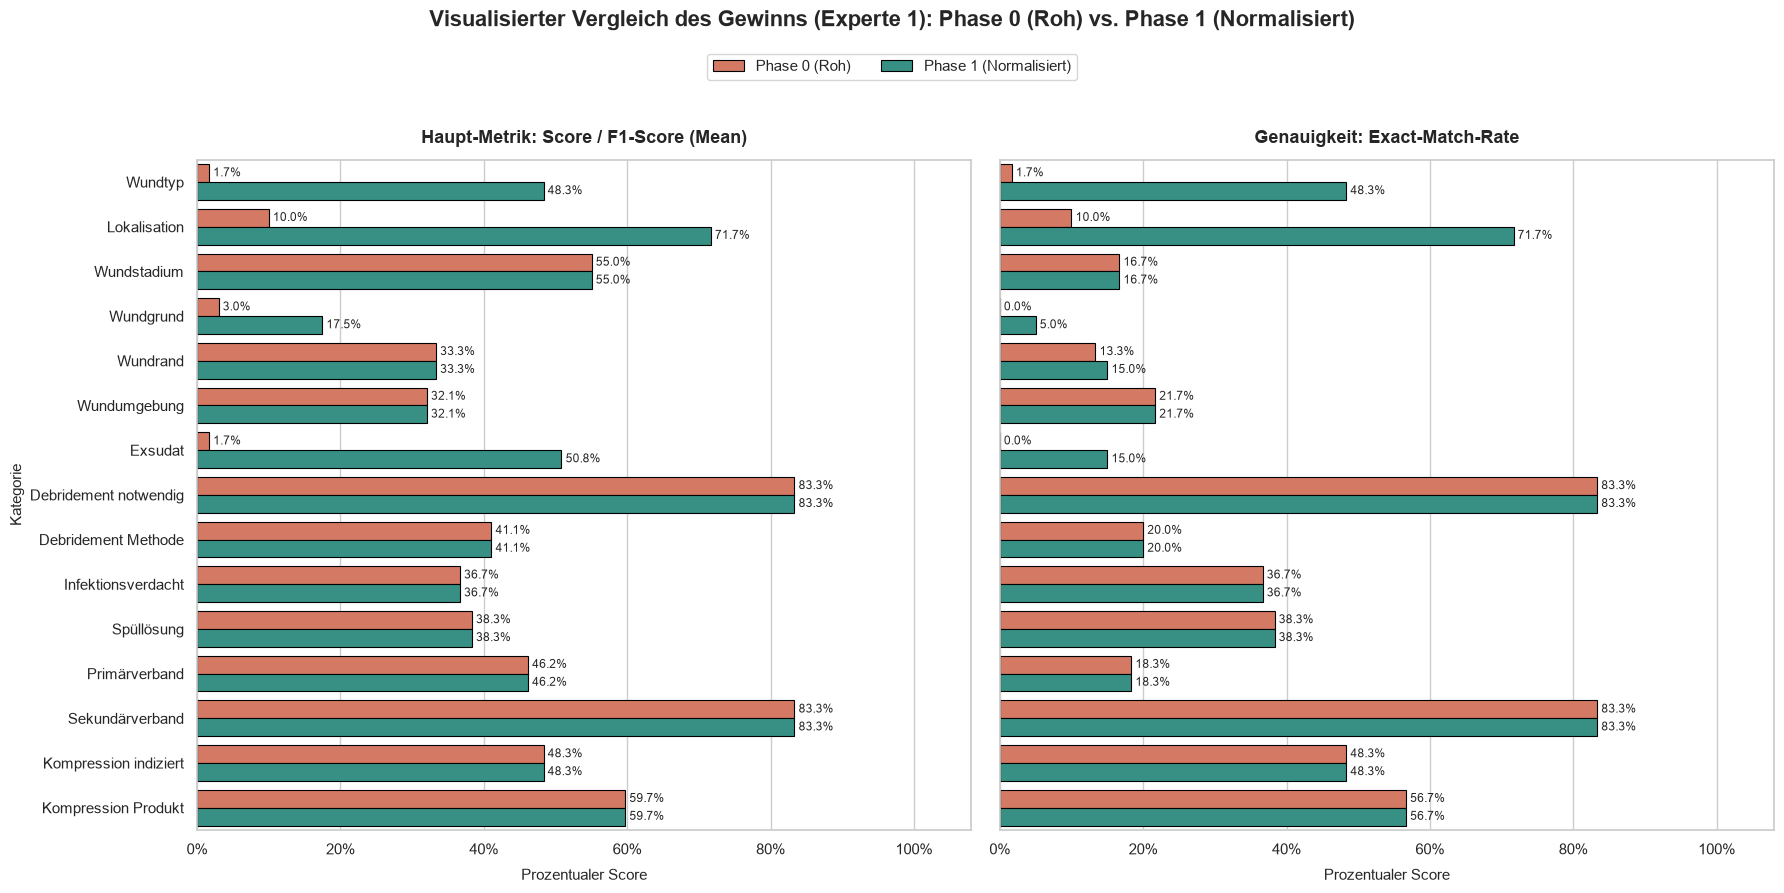

=== 2. SCORE ZWISCHEN LLM UND EXPERTEN (BEST-MATCH EXPERTE 1 & 2) ===


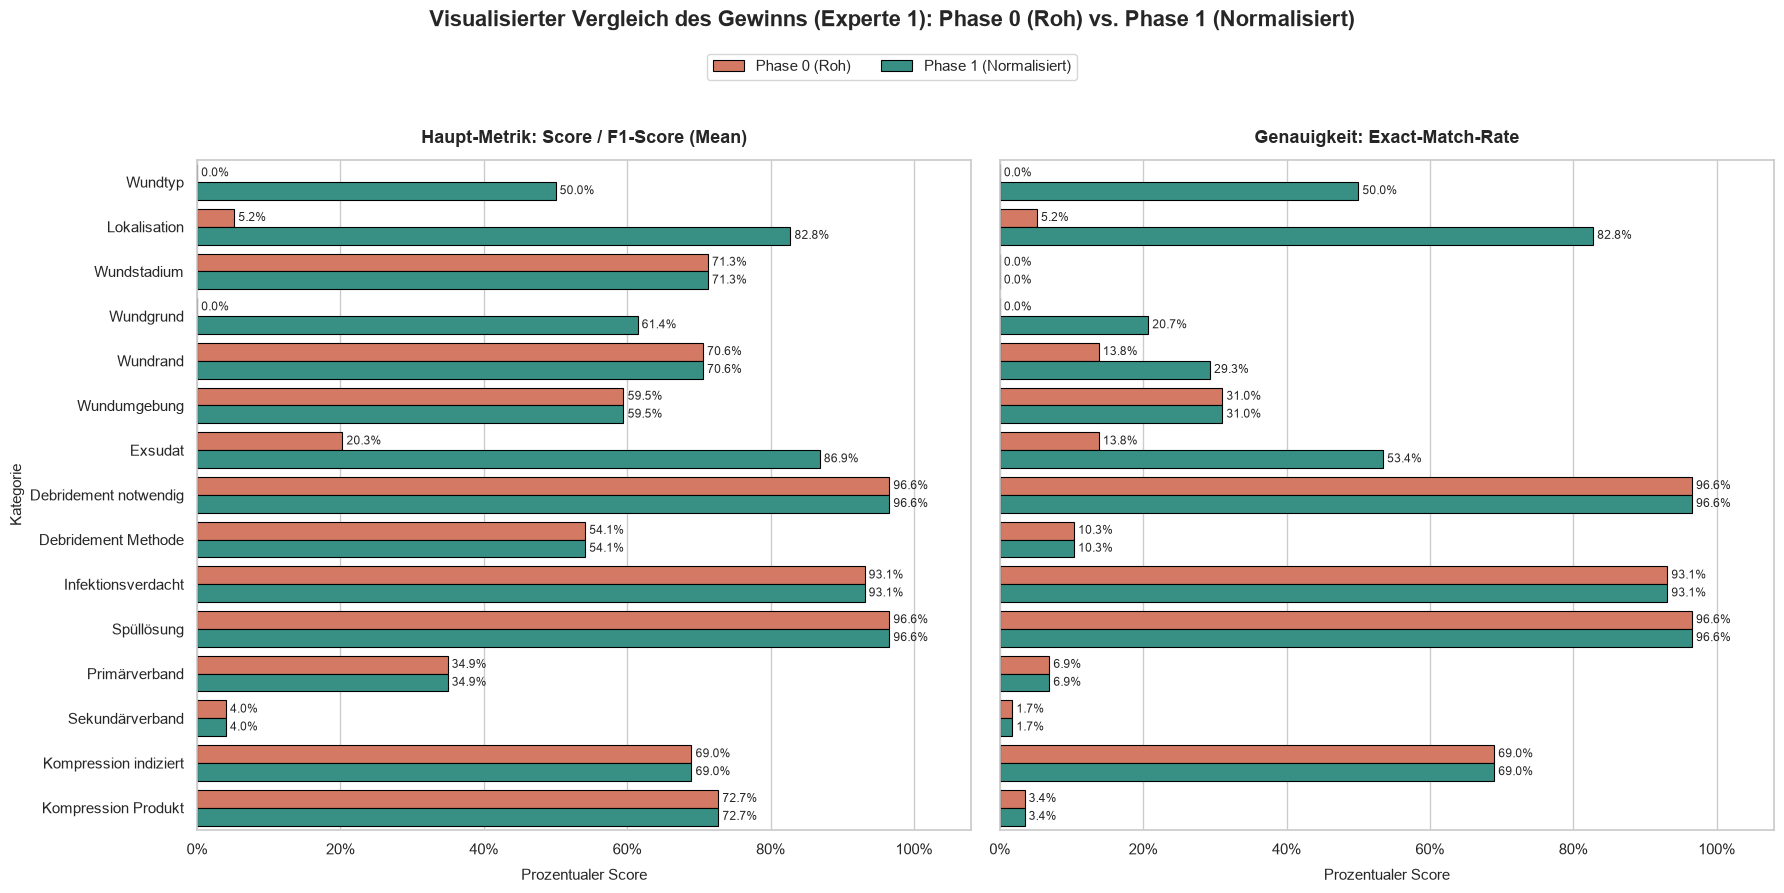

=== 3. SCORES NACH PUNKTEN GEORDNET (HÖCHSTE GANZ OBEN) ===


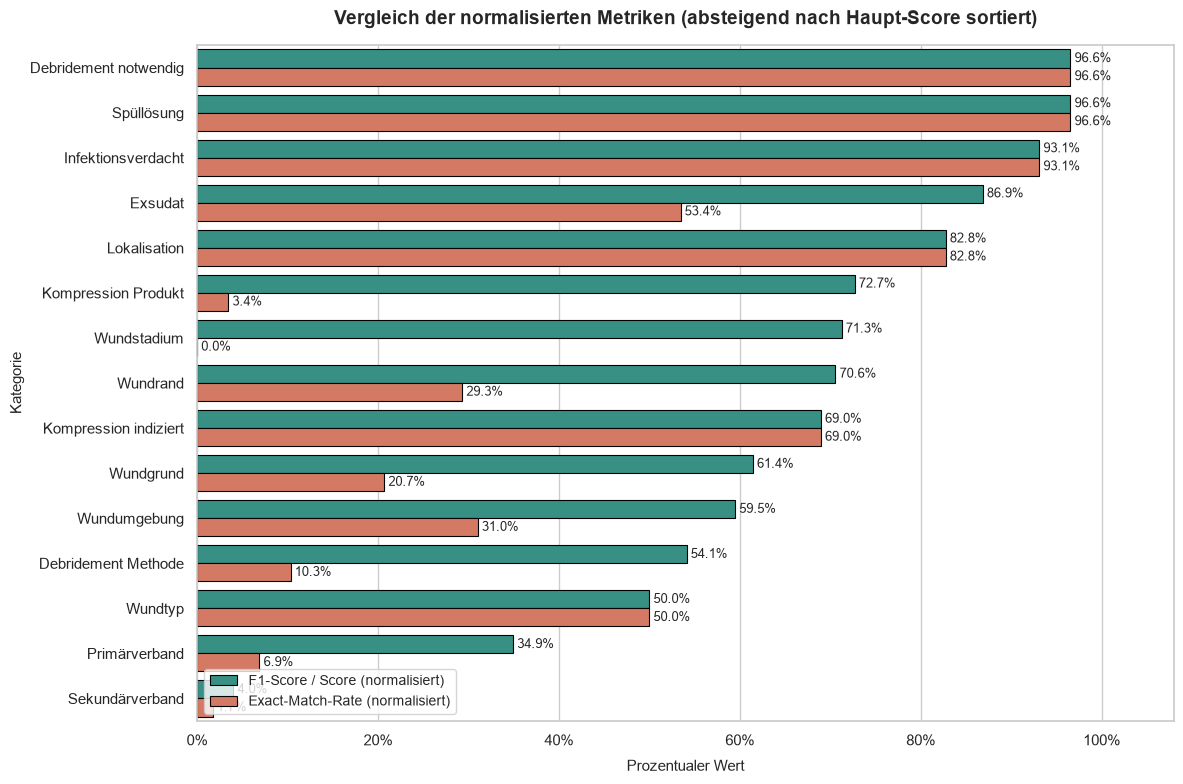

In [11]:
# =====================================================================
# ZUSAMMENFASSENDE DIAGRAMME UNTEREINANDER
# =====================================================================
from utils_notebook.plot_compare import plot_gt_comparison, plot_sorted_norm_comparison
from utils_notebook.LR_utils_notebook.compare_LR import (
    calculate_experts_summary_LR,
    calculate_consensus_summary_LR
)

# 1. Score-Einigkeit zwischen Experte 1 und Experte 2
print("=== 1. SCORE-EINIGKEIT ZWISCHEN EXPERTE 1 UND EXPERTE 2 ===")
df_exp_raw = calculate_experts_summary_LR(normalised=False)
df_exp_norm = calculate_experts_summary_LR(normalised=True)
plot_gt_comparison(df_exp_raw, df_exp_norm)

# 2. Score zwischen LLM und Experten (Best-of-Both Konsens)
print("=== 2. SCORE ZWISCHEN LLM UND EXPERTEN (BEST-MATCH EXPERTE 1 & 2) ===")
df_consensus_raw = calculate_consensus_summary_LR(normalised=False, path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)
df_consensus_norm = calculate_consensus_summary_LR(normalised=True, path_llm_raw=FEW_SHOT_RAW, path_llm_norm=FEW_SHOT_NORM)
plot_gt_comparison(df_consensus_raw, df_consensus_norm)

# 3. Scores nach Punkten geordnet (höchste ganz oben)
print("=== 3. SCORES NACH PUNKTEN GEORDNET (HÖCHSTE GANZ OBEN) ===")
plot_sorted_norm_comparison(df_consensus_norm)


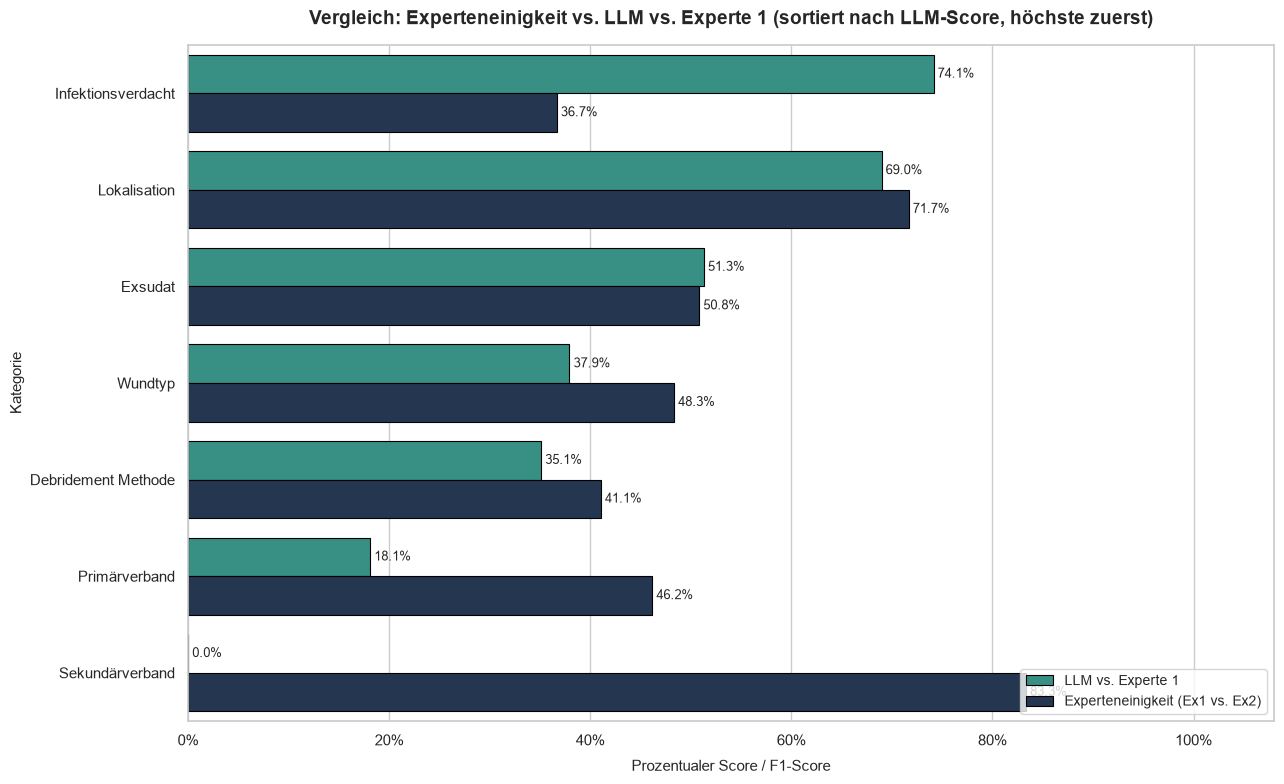

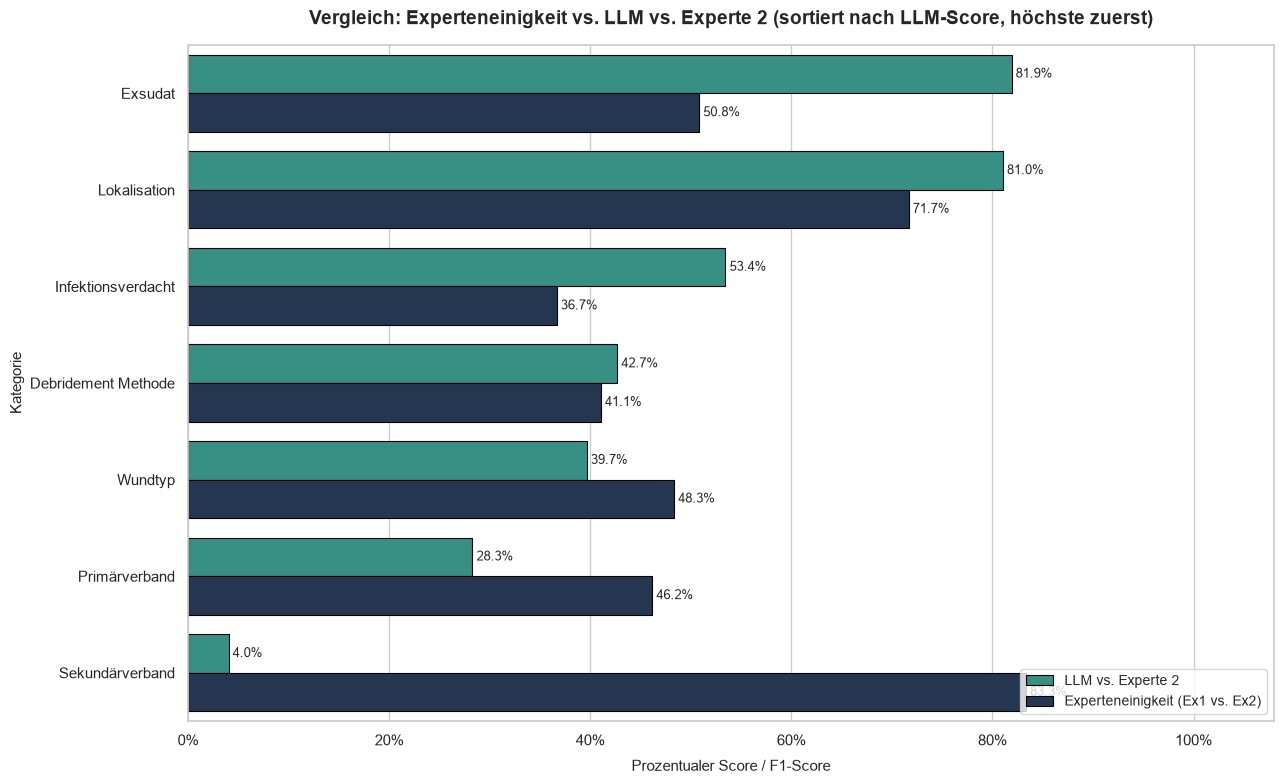

In [12]:
from utils_notebook.plot_compare import plot_combined_single_chart
from utils_notebook.LR_utils_notebook.compare_LR import calculate_summary_LR, calculate_experts_summary_LR

# 1. Daten berechnen (normalisiert)
df_experts_norm = calculate_experts_summary_LR(normalised=True)
df_exp1_norm = calculate_summary_LR(expert_id=1, normalised=True, path_llm_norm=FEW_SHOT_NORM)
df_exp2_norm = calculate_summary_LR(expert_id=2, normalised=True, path_llm_norm=FEW_SHOT_NORM)

# 2. Ausgewählte Kategorien filtern
selected_categories = [
    'Wundtyp',
    'Exsudat',
    'Lokalisation',
    'Debridement Methode',
    'Primärverband',
    'Sekundärverband',
    'Infektionsverdacht'
]  

df_experts_filtered = df_experts_norm[df_experts_norm['Kategorie'].isin(selected_categories)]
df_exp1_filtered = df_exp1_norm[df_exp1_norm['Kategorie'].isin(selected_categories)]
df_exp2_filtered = df_exp2_norm[df_exp2_norm['Kategorie'].isin(selected_categories)]

# 3. Plot 1: LLM vs. Experte 1 & Experteneinigkeit (gefiltert, sortiert nach LLM vs. Experte 1)
plot_combined_single_chart(df_experts_filtered, df_exp1_filtered, expert_label='Experte 1')

# 4. Plot 2: LLM vs. Experte 2 & Experteneinigkeit (gefiltert, sortiert nach LLM vs. Experte 2)
plot_combined_single_chart(df_experts_filtered, df_exp2_filtered, expert_label='Experte 2')
